# VisDrone Dataset Visualization

This notebook gives a compact view of split sizes and class balance across the local VisDrone detection dataset.

In [7]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import pandas as pd

from src.analysis import (
    build_class_distribution_frame,
    build_split_summary_and_class_counts,
    collect_bbox_metrics,
    collect_bbox_size_data,
    collect_small_images,
    inspect_dataset_issues,
    remove_issue_files,
    summarize_bbox_size_distribution,
)
from src.visualization import visualize_random_samples
from src.visualization_helpers import (
    plot_bbox_distributions,
    plot_class_distribution,
    plot_split_summary,
)

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


In [8]:
DATA_DIR = Path("./data")

summary_df, class_distributions = build_split_summary_and_class_counts(DATA_DIR)
summary_df


{'split': 'train', 'images': 6471, 'label_files': 6471, 'boxes': 353550, 'avg_boxes_per_image': 54.64}
{'split': 'test', 'images': 1610, 'label_files': 1610, 'boxes': 77547, 'avg_boxes_per_image': 48.17}
{'split': 'val', 'images': 548, 'label_files': 548, 'boxes': 40169, 'avg_boxes_per_image': 73.3}


,split,images,label_files,boxes,avg_boxes_per_image,image_share
0,train,6471,6471,353550,54.64,0.75
1,test,1610,1610,77547,48.17,0.19
2,val,548,548,40169,73.30,0.06


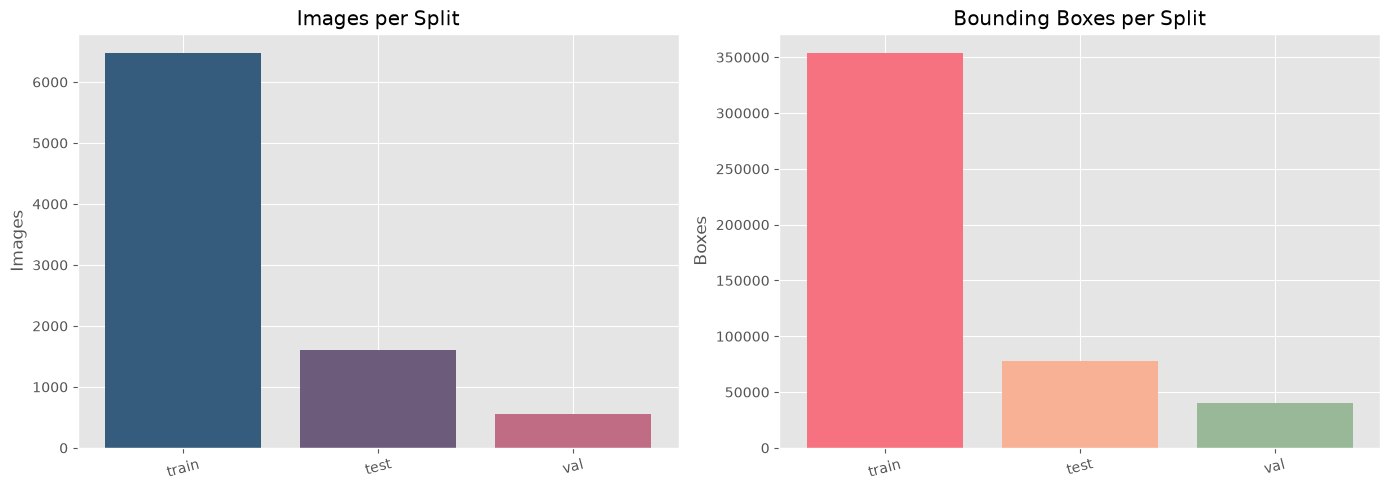

In [9]:
plot_split_summary(summary_df)
plt.show()


In [10]:
class_df = build_class_distribution_frame(class_distributions)
class_df


,train,test,val,total
others,1532,265,32,1829
awning_tricycle,3246,599,532,4377
tricycle,4812,530,1045,6387
bus,5926,2940,251,9117
ignored_regions,8813,2180,1378,12371
bicycle,10480,1302,1287,13069
truck,12875,2659,750,16284
van,24956,5771,1975,32702
people,27059,6376,5125,38560
motor,29647,5845,4886,40378


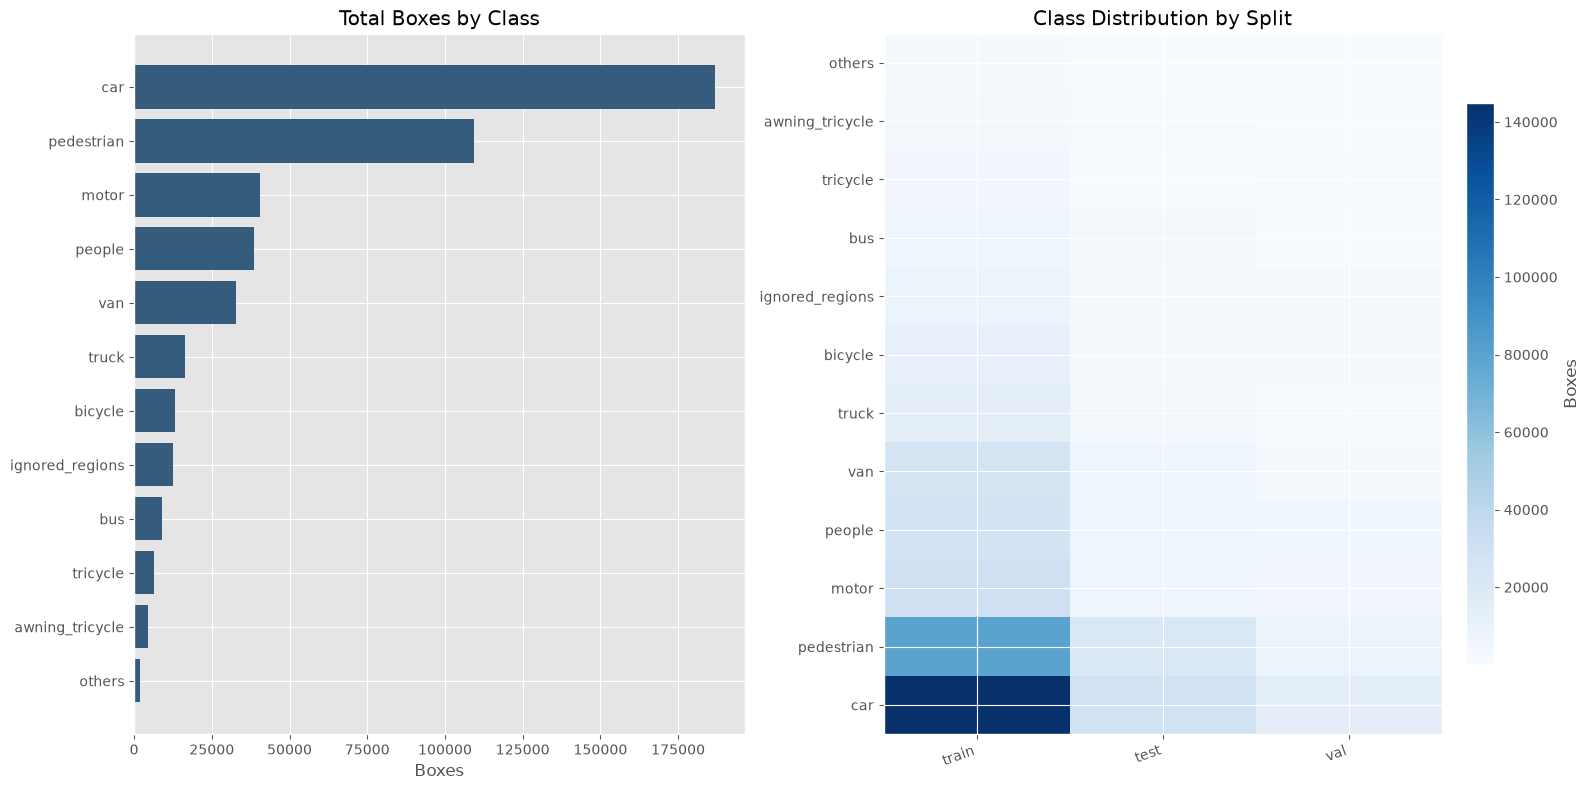

In [11]:
plot_class_distribution(class_df)
plt.show()


In [12]:
bbox_df = collect_bbox_metrics(DATA_DIR)

bbox_df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])


,width,height,area,aspect_ratio
count,"471,266.00","471,266.00","471,266.00","471,266.00"
mean,37.19,36.19,"2,286.28",1.09
std,40.18,32.93,"6,342.56",0.70
min,2.00,0.00,0.00,0.00
10%,7.00,10.00,90.00,0.41
25%,13.00,16.00,224.01,0.56
50%,24.00,26.00,637.99,0.89
75%,47.00,44.00,"1,886.01",1.44
90%,82.00,72.00,"5,291.98",2.10
max,"1,424.00",790.00,"355,432.35",31.27


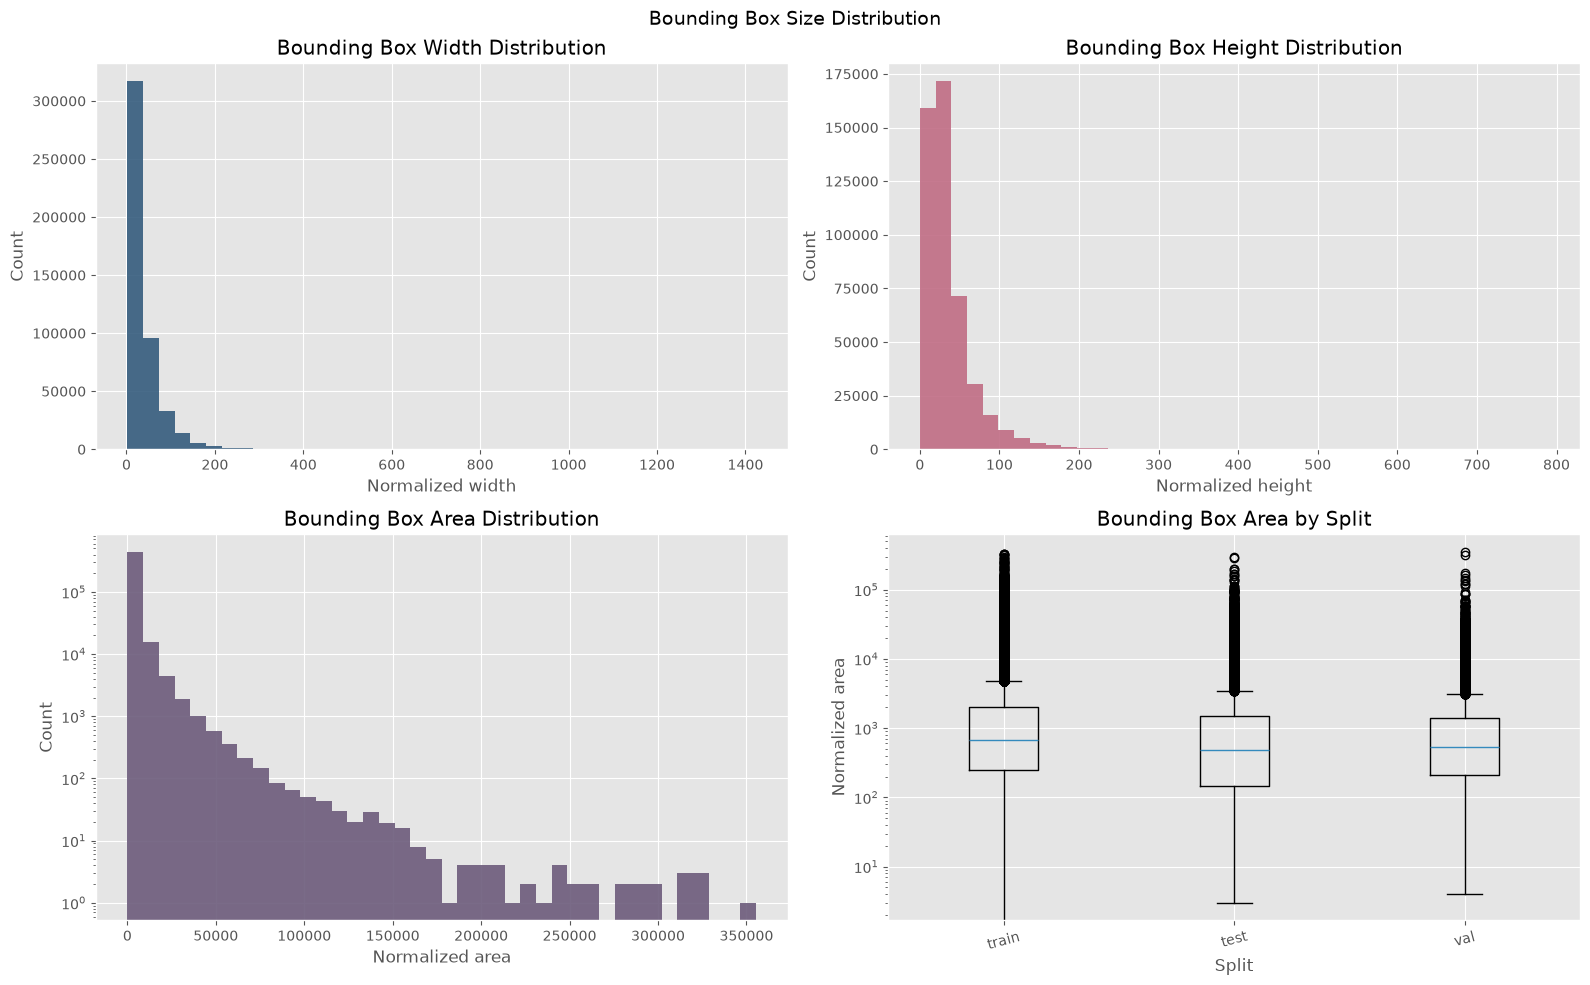

In [13]:
plot_bbox_distributions(bbox_df, summary_df)
plt.show()


In [14]:
bbox_size_rows, bbox_size_df = collect_bbox_size_data(DATA_DIR)
size_distribution, size_distribution_by_split = summarize_bbox_size_distribution(bbox_size_df)

print("Overall box size distribution (COCO-style thresholds in pixel area):")
display(size_distribution)
print("\nBox size distribution by split (%):")
size_distribution_by_split


Overall box size distribution (COCO-style thresholds in pixel area):


,percentage
size_bucket,
small,62.00
medium,32.97
large,5.03



Box size distribution by split (%):


size_bucket,small,medium,large
split,,,
test,67.38,29.33,3.29
train,60.16,34.19,5.64
val,67.76,29.25,2.99


Reading images from /home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/data/images/train


/home/stiro/anaconda3/envs/image-object-detection/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing hashes: 100%|██████████| 6471/6471 [00:23<00:00, 272.45it/s]


Issue checks completed. 40 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | blurry           |           19 |
|  1 | dark             |           15 |
|  2 | exact_duplicates |            4 |
|  3 | near_duplicates  |            2 |
|  4 | light            |            0 |
|  5 | low_information  |            0 |
|  6 | odd_aspect_ratio |            0 |
|  7 | odd_size         |            0 |
|  8 | grayscale        |            0 | 

---------------------- blurry images -----------------------

Number of examples with this issue: 19
Examples representing most severe instances of this issue:



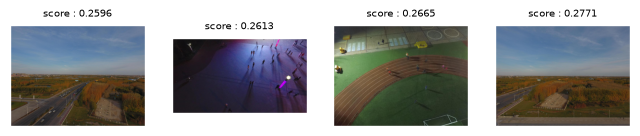

----------------------- dark images ------------------------

Number of examples with this issue: 15
Examples representing most severe instances of this issue:



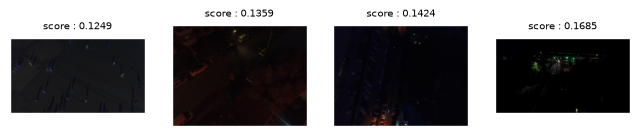

----------------- exact_duplicates images ------------------

Number of examples with this issue: 4
Examples representing most severe instances of this issue:

Set: 0


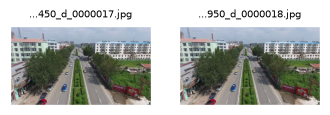

Set: 1


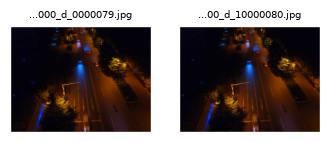

------------------ near_duplicates images ------------------

Number of examples with this issue: 2
Examples representing most severe instances of this issue:

Set: 0


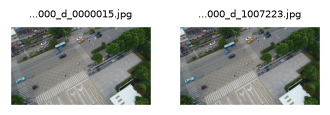

Reading images from /home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/data/images/test
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing hashes: 100%|██████████| 1610/1610 [00:04<00:00, 378.63it/s]


Issue checks completed. 0 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | dark             |            0 |
|  1 | light            |            0 |
|  2 | odd_aspect_ratio |            0 |
|  3 | low_information  |            0 |
|  4 | blurry           |            0 |
|  5 | grayscale        |            0 |
|  6 | odd_size         |            0 |
|  7 | exact_duplicates |            0 |
|  8 | near_duplicates  |            0 | 

Reading images from /home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/data/images/val
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing hashes: 100%|██████████| 548/548 [00:01<00:00, 375.05it/s]


Issue checks completed. 143 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | odd_size         |          140 |
|  1 | exact_duplicates |            2 |
|  2 | dark             |            1 |
|  3 | light            |            0 |
|  4 | odd_aspect_ratio |            0 |
|  5 | blurry           |            0 |
|  6 | low_information  |            0 |
|  7 | grayscale        |            0 |
|  8 | near_duplicates  |            0 | 

--------------------- odd_size images ----------------------

Number of examples with this issue: 140
Examples representing most severe instances of this issue:



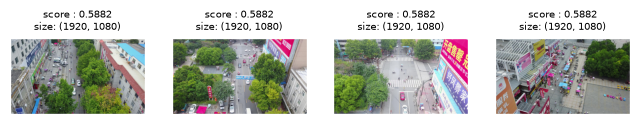

----------------- exact_duplicates images ------------------

Number of examples with this issue: 2
Examples representing most severe instances of this issue:

Set: 0


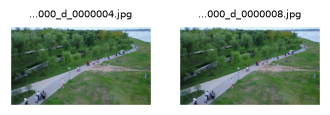

----------------------- dark images ------------------------

Number of examples with this issue: 1
Examples representing most severe instances of this issue:



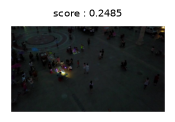

In [15]:
inspection_results = inspect_dataset_issues(DATA_DIR)


In [ ]:
# logger = logging.Logger("Logger", 0) 
# remove_issue_files(inspection_results, logger=logger)


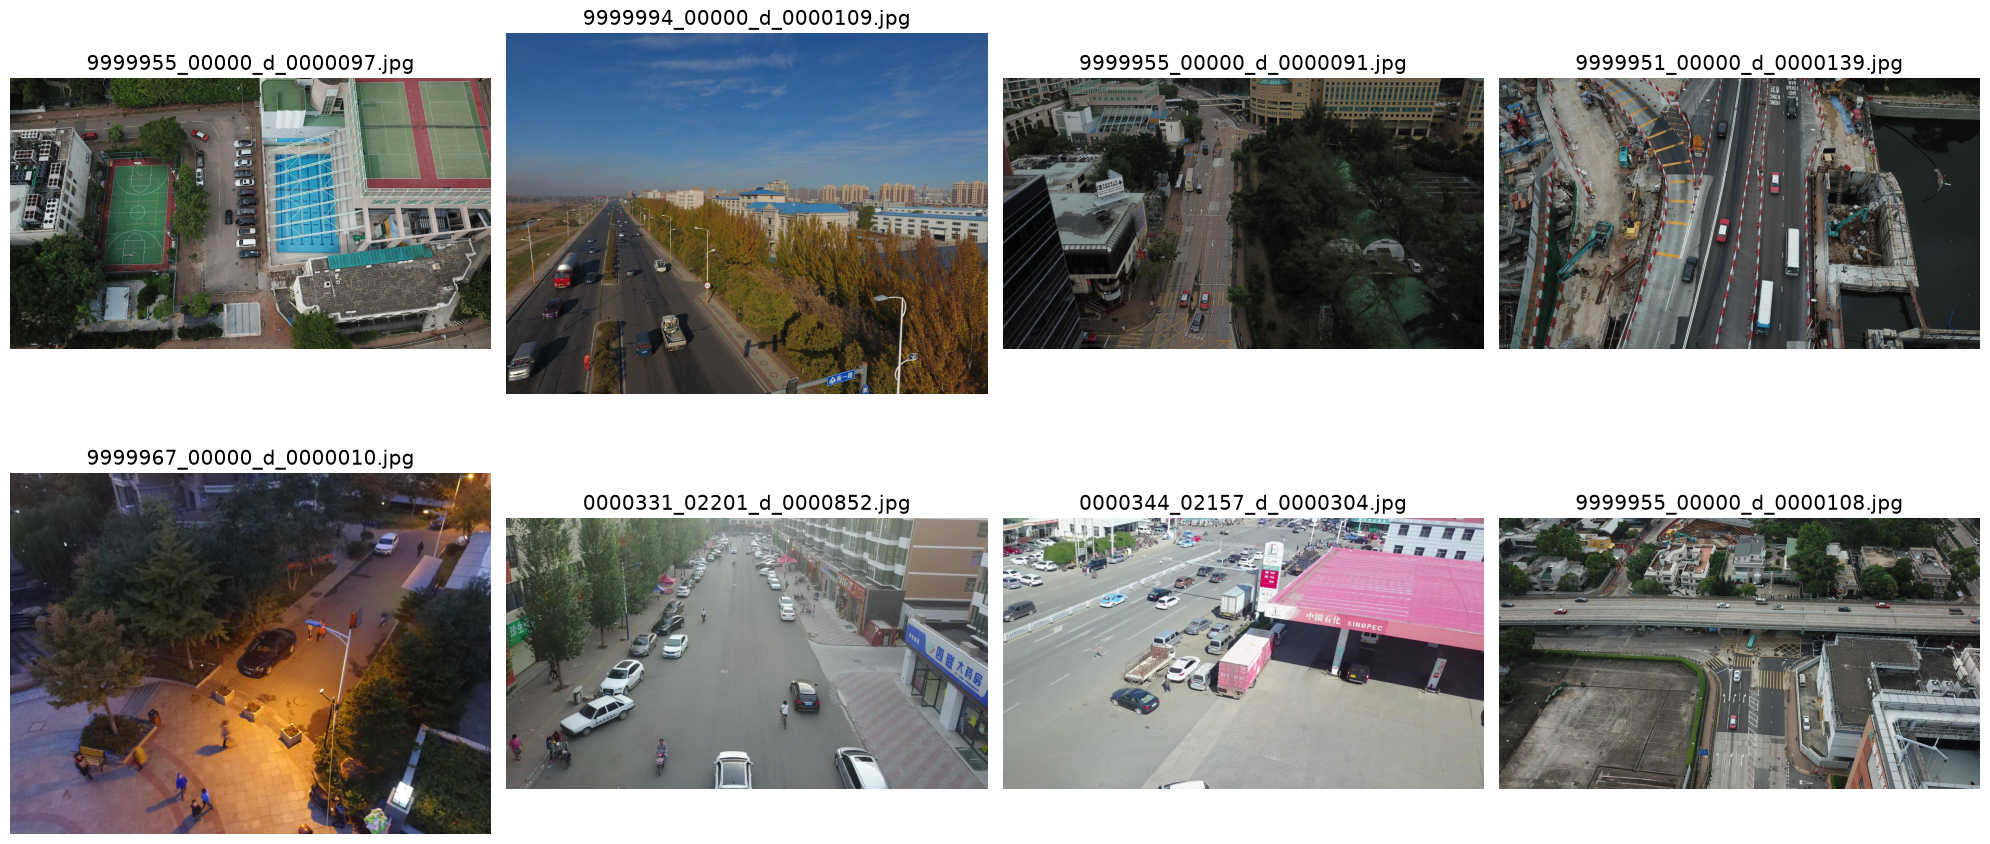

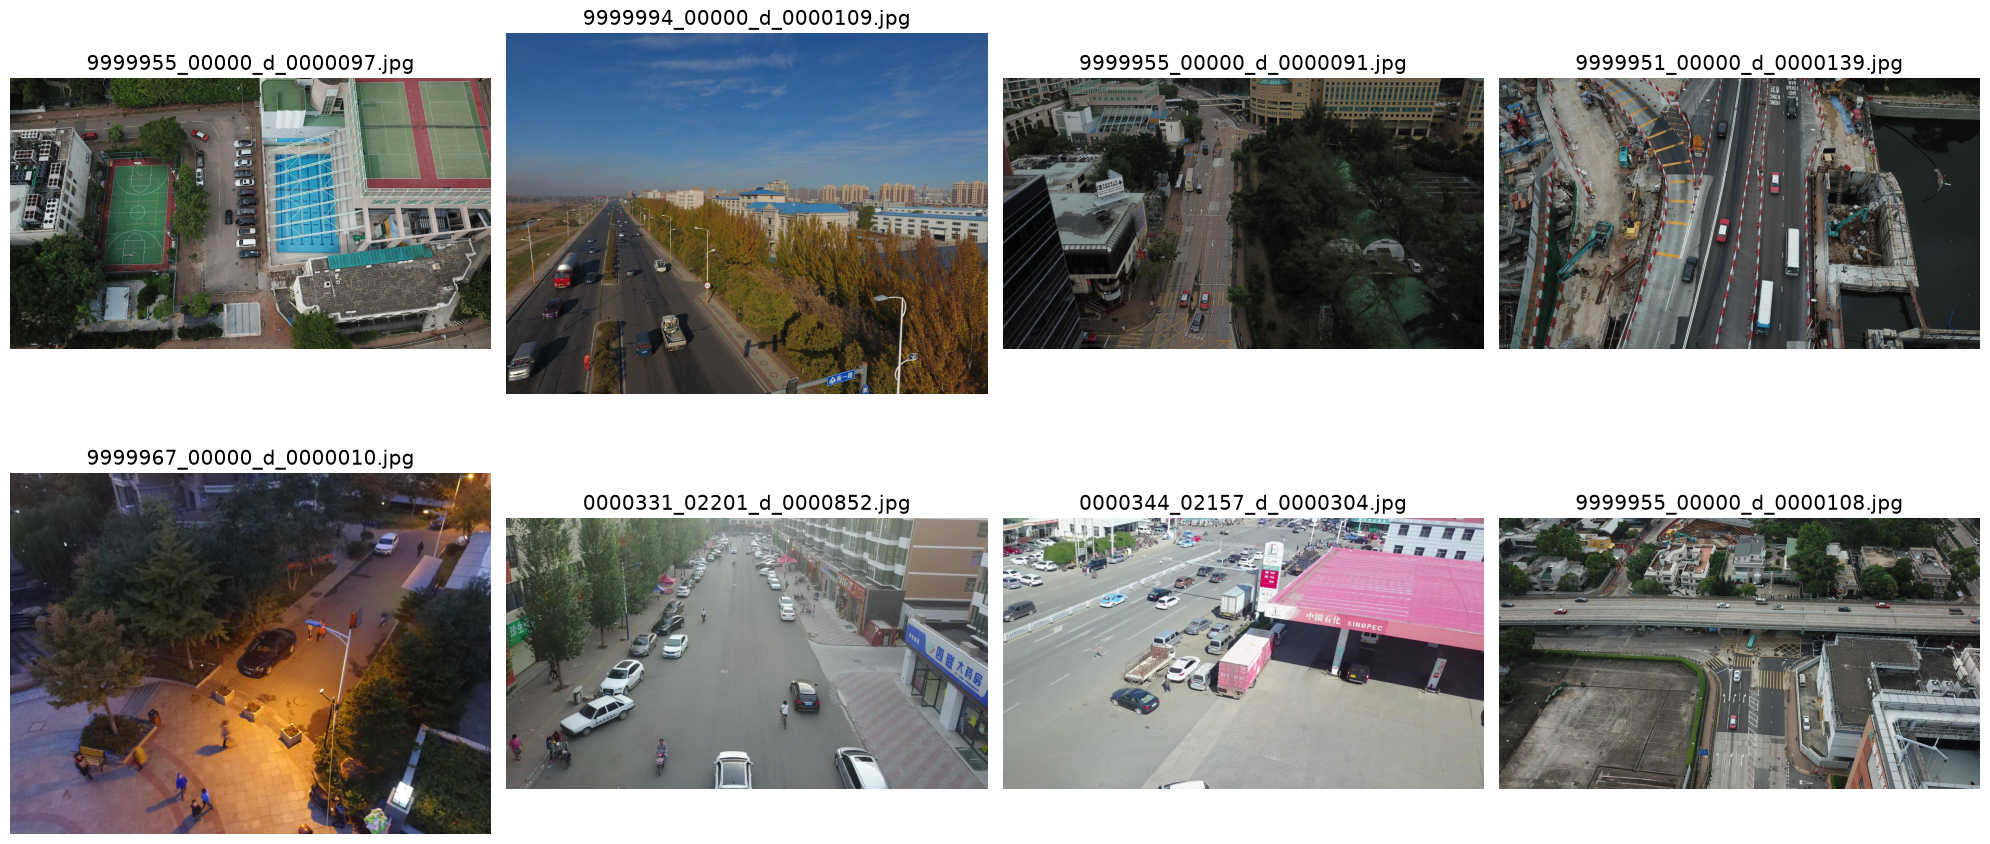

In [21]:
visualize_random_samples(DATA_DIR, "train", class_ids=[1])


In [ ]:
small_images = collect_small_images(bbox_size_rows, split_name="train")

